In [20]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel , Field
import operator


In [21]:
load_dotenv()

True

In [22]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

In [23]:
class sentiment_schema(BaseModel):

    sentiment: Literal["Positive", "negative"] = Field(description='sentiment of review')

In [24]:
class diagnosis_schema(BaseModel):

    issue_type : Literal["UX", "performance", "bug", "support", "other"] = Field(description= ' The category of issue mentioned in the review')
    tone : Literal["angry", "frustrated", "dissapointed", "calm"] = Field(description='the emotional tone expressed by the user')
    urgency : Literal["low", "medium", "high"] = Field(description= 'How urgent or critical is the issue')

In [25]:
structured_model = model.with_structured_output(sentiment_schema)
structured_model2 = model.with_structured_output(diagnosis_schema)

In [26]:
prompt = 'What is the sentiment of the following review - The software is too bad'  
structured_model.invoke(prompt)

sentiment_schema(sentiment='negative')

In [27]:
class reviewstate(TypedDict):
    review : str
    sentiment : Literal["Positive", "negative"]
    diagnosis : dict
    response : str

In [28]:
def find_sentiment(state: reviewstate):

    prompt  =   f'For the following review find out the sentiment \n {state['review']}'

    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment' : sentiment}

def check_sentiment(state : reviewstate) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'Positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    

def positive_response(state : reviewstate):

    prompt = f"""Write a warm thankyou message in response to this review : \n\n {state['review']} \n Also kindly ask the user to leave a feedback on our website
"""
    response = model.invoke(prompt).content

    return {'response' : response}



def run_diagnosis(state:reviewstate):

    prompt = f""" Diagnose this  negative review : \n\n{state['review']}\n return issue_type, tone, and urgency
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()} #to convert to dict


def negative_response(state : reviewstate):
    diagnosis = state['diagnosis']
    prompt = f"""you are a support assistant. the user had a '{diagnosis['issue_type']}', sounded '{diagnosis['tone']}' and marked urgency as '{diagnosis['urgency']}' write a helpful, emphatic resolution message.
"""
    response = model.invoke(prompt).content

    return {'response' : response}
    

In [29]:
graph = StateGraph(reviewstate)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('negative_response', negative_response)
graph.add_node('run_diagnosis', run_diagnosis)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()


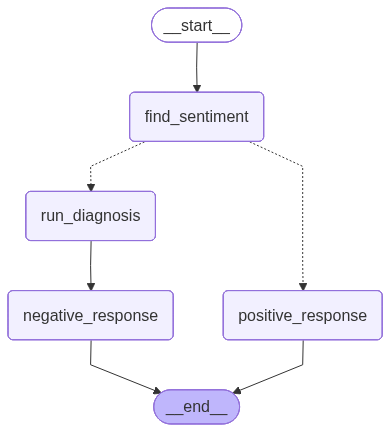

In [30]:
workflow

In [ ]:
initial_state = {
    'review' : "I have been using this app for about a month now, and I must say the user interface is increadibly clean and intuitive. everything is exactly where you'd expect it to be. great job design team"
}

workflow.invoke(initial_state)